<a href="https://colab.research.google.com/drive/1N2iEW-PMQiFTAL1GSYDADZZITtKSmwCU#scrollTo=xFazOG6BItfj" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MRI segmentation with 3D U-Net

## Running locally

Written for Google Colab (GPU runtime). On your own machine:

1. Fresh environment, pinned deps:

   ```bash
   python3.12 --version
   python3.12 -m venv .venv
   source .venv/bin/activate

   python -m pip install --upgrade pip setuptools wheel
   python -m pip install -r requirements.txt

   python -m ipykernel install --user \
   --name mri-3dunet-py312 \
   --display-name "Python 3.12 (MRI 3D UNet)"
   ```

   `requirements.txt` pulls the surface-distance package from GitHub, so you need `git` on your PATH.

2. You want a CUDA GPU. Whole-volume 3D U-Net training is heavy - the whole-image section takes ~25 min on a GPU and is not practical on CPU. CPU only? Set `num_epochs = 1` and skip to the patch-based section just to watch the pipeline run.

3. `num_workers=multiprocessing.cpu_count()` hangs on Windows. Use `num_workers=0` there.

The `!pip install` lines below are a Colab convenience - locally, install once from `requirements.txt` instead.

## 1. Introduction

We're segmenting gray matter and subcortical nuclei from preprocessed MRI. Unlike parts 1 and 2, where we predicted one label per *subject*, here we predict a label for every *voxel* - a full 3D mask. This is where deep learning earns its keep in medical imaging: doing it by hand takes a radiologist hours per brain.

The model is a 3D U-Net. Input is a FreeSurfer-normalised `T1`; target is the `aparc+aseg` mask from `recon-all`.

**What we actually train here is a *binary* model** - brain-structure vs background. The `aseg` file contains dozens of distinct anatomical labels (the table further down lists some), but `prepare_batch` collapses them all to 1 and everything else to 0. That's a deliberate simplification to keep training tractable in a seminar. Section 5 at the end sets up the multi-class version as an exercise.

*By running this you confirm your personal access to the [HCP data](https://www.humanconnectome.org/study/hcp-young-adult/document/1200-subjects-data-release) and agreement to its [terms and conditions](https://www.humanconnectome.org/study/hcp-young-adult/data-use-terms).*

Code adapted from the [TorchIO](https://torchio.readthedocs.io/) tutorials.

## 2. Setup and data

Pin the libraries. Colab's preinstalled versions drift and `torchio`/`unet` have both changed APIs across releases.

In [ ]:
# Colab: install pinned deps. Locally: use requirements.txt instead and skip this cell.
# !pip install -q torchio unet nilearn SimpleITK
# !pip install -q git+https://github.com/google-deepmind/surface-distance.git

In [4]:
import os, sys, time, enum, random, warnings, multiprocessing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel
from tqdm import tqdm
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchio
from torchio import AFFINE, DATA, PATH, TYPE, STEM
from unet import UNet

# DSC / average-surface-distance metrics. The original notebook CALLED these but
# never imported them - it would NameError on a clean run.
from surface_distance import (
    compute_dice_coefficient,
    compute_surface_distances,
    compute_average_surface_distance,
)

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    print("WARNING: no GPU - training will be impractically slow. Switch the runtime to GPU.")
print("device:", device)

/workspace/seminar5_neuroml/mri_3DUnet/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu


/workspace/seminar5_neuroml/mri_3DUnet/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


### Getting the data

The segmentation data is large. If the download dies partway, re-run the cell - it skips what's already on disk.

In [ ]:
!pip install -q gdown==5.2.0

from pathlib import Path
import gdown

data_root = Path("data")
data_root.mkdir(exist_ok=True)

data_dir = data_root / "fs_segmentation"                        # norm + aseg volumes
labels_csv = data_root / "unrestricted_hcp_freesurfer.csv"      # demographics (for the Subject list)

Download data files, namely fs_segmentation.zip, unrestricted_hcp_freesurfer.csv and labels.npy, from https://cloud.appliedai.tech/s/6wXEsjEiJJLRyyA?path=%2FSeminar%205%2Fmri_3DUnet. \
Place them into the data folder. \
Run ```unzip fs_segmentation.zip```.

In [5]:
print("files in", data_dir, ":", len(os.listdir(data_dir)))

files in data/fs_segmentation : 855


## 3. Building the subject list

Each subject contributes two files: a `norm` volume (the input) and an `aseg` volume (the target). We pair them by subject ID.

In [7]:
labels = pd.read_csv(labels_csv)

# map: subject id -> {'norm': path, 'aseg': path}
paired = {}
for fname in os.listdir(data_dir):
    for sid in labels['Subject']:
        if str(sid) in fname:
            kind = 'norm' if 'norm' in fname else ('aseg' if 'aseg' in fname else None)
            if kind:
                paired.setdefault(sid, {})[kind] = str(data_dir / fname)
            break

# keep only subjects that have BOTH files
data_list = pd.DataFrame(
    [{'Subject': sid, 'norm': v['norm'], 'aseg': v['aseg']}
     for sid, v in paired.items() if 'norm' in v and 'aseg' in v]
).sort_values('Subject').reset_index(drop=True)

print(f"{len(data_list)} subjects with a complete norm+aseg pair")
data_list.head()

427 subjects with a complete norm+aseg pair


,Subject,norm,aseg
0,101006,data/fs_segmentation/HCP_T1_fs6_101006_norm.ni...,data/fs_segmentation/HCP_T1_fs6_101006_aparc+a...
1,101107,data/fs_segmentation/HCP_T1_fs6_101107_norm.ni...,data/fs_segmentation/HCP_T1_fs6_101107_aparc+a...
2,101309,data/fs_segmentation/HCP_T1_fs6_101309_norm.ni...,data/fs_segmentation/HCP_T1_fs6_101309_aparc+a...
3,101410,data/fs_segmentation/HCP_T1_fs6_101410_norm.ni...,data/fs_segmentation/HCP_T1_fs6_101410_aparc+a...
4,101915,data/fs_segmentation/HCP_T1_fs6_101915_norm.ni...,data/fs_segmentation/HCP_T1_fs6_101915_aparc+a...


Sanity-check by eye: the T1 and its segmentation.

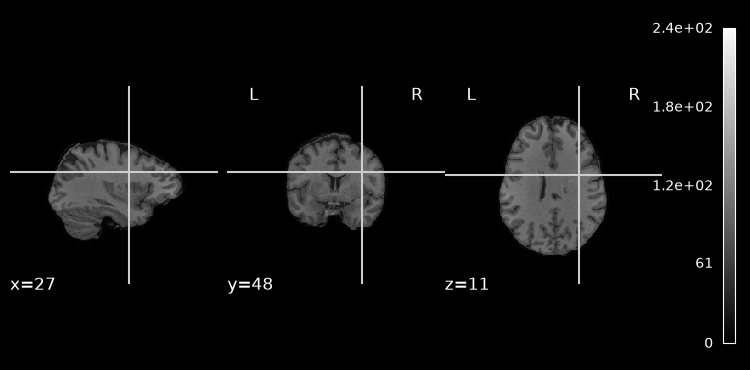

In [8]:
from nilearn import plotting
import nilearn

plotting.plot_anat(nilearn.image.load_img(data_list['norm'].iloc[0]))

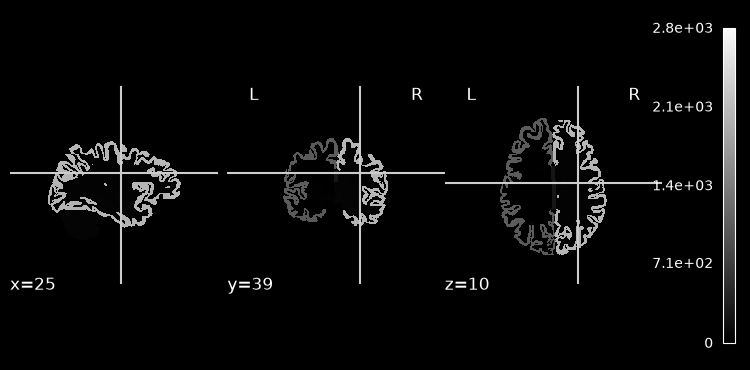

In [9]:
seg_img = nilearn.image.load_img(data_list['aseg'].iloc[0])
plotting.plot_anat(seg_img)

Those aren't intensities - they're **label IDs**. Every distinct number is a different anatomical structure.

In [10]:
np.unique(seg_img.dataobj)

array([   0,    2,    3,    4,    5,    7,    8,   10,   11,   12,   13,
         14,   15,   16,   17,   18,   24,   26,   28,   30,   31,   41,
         42,   43,   44,   46,   47,   49,   50,   51,   52,   53,   54,
         58,   60,   62,   63,   77,   85,  251,  252,  253,  254,  255,
       1000, 1001, 1002, 1003, 1005, 1006, 1007, 1008, 1009, 1010, 1011,
       1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022,
       1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033,
       1034, 1035, 2000, 2001, 2002, 2003, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031,
       2032, 2033, 2034, 2035], dtype=int32)

| Structure | Seg ID |
| ----------------- | ----|
| Left-Lateral-Ventricle | 4 |
| Left-Inf-Lat-Vent | 5 |
| 3rd-Ventricle | 14 |
| 4th-Ventricle | 15 |
| Brain Stem | 16 |
| Left Hippocampus | 17 |
| Left Amygdala | 18 |
| Right-Lateral-Ventricle | 43 |
| Right-Inf-Lat-Vent | 44|
| Right Hippocampus | 53 |
| Right Amygdala | 54 |
| 5th-Ventricle | 72 |

1. Ventrices - cognitive impairment, aging, Alzheimer's. [1](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6601311/)

2. Brain Stem - cognitive impairment,  metabolic pathway disorders (Parkinson): [2](https://pubmed.ncbi.nlm.nih.gov/15240431/), [3](
https://pubs.rsna.org/doi/full/10.1148/rg.2019180126)


2. Hippocampus and Amygdala - autism spectrum disorders, epilepsy [4](https://d-nb.info/1137998318/34)





![Ventricels](https://www.thoughtco.com/thmb/jT1auUqpiaZNZjg-9AHX3eq9yrA=/768x0/filters:no_upscale():max_bytes(150000):strip_icc():format(webp)/brain_ventricles-56d0ccd03df78cfb37b876dc.jpg)

## 4. Dataset, transforms, and split

`torchio.Image` reads the volumes, `torchio.Subject` bundles a scan with its mask, `torchio.SubjectsDataset` serves them.

In [11]:
import torchio
import enum
"""
    Code adapted from: https://github.com/fepegar/torchio#credits

        Credit: Pérez-García et al., 2020, TorchIO:
        a Python library for efficient loading, preprocessing,
        augmentation and patch-based sampling of medical images in deep learning.

"""

CHANNELS_DIMENSION = 1
SPATIAL_DIMENSIONS = 2, 3, 4

MRI = 'MRI'
LABEL = 'LABEL'

LIST_ASEG =  [ 8,   10,   11,   12,   13,    16,   17,   18,  26,  47, 49,   50,
  51,   52,   53,   54,   58,  85,  251,  252,  253,  254,  255] # gray matter segmentation labels

class Action(enum.Enum):
    TRAIN = 'Training'
    VALIDATE = 'Validation'

def get_torchio_dataset(inputs, targets, transform):
    """
    The function creates dataset from the list of files from cunstumised dataloader.
    """
    subjects = []
    for (image_path, label_path) in zip(inputs, targets):
        subject_dict = {
            MRI : torchio.Image(image_path, torchio.INTENSITY),
            LABEL: torchio.Image(label_path, torchio.LABEL),
        }
        subject = torchio.Subject(subject_dict)
        subjects.append(subject)

    if transform:
        dataset = torchio.SubjectsDataset(subjects, transform = transform)
    elif not transform:
        dataset = torchio.SubjectsDataset(subjects)

    return  dataset , subjects

In [12]:
data, subjects = get_torchio_dataset(
    data_list['norm'].values, data_list['aseg'].values, transform=False
)
print("dataset size:", len(data))

dataset size: 427


### Visualisation helpers for 3D tensors

In [13]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import nibabel

def plot_central_cuts(img, title=""):
    """
    param image: tensor or np array of shape (CxDxHxW) if t is None
    """
    if isinstance(img, torch.Tensor):
        img = img.numpy()
        if (len(img.shape) > 3):
            img = img[0,:,:,:]

    elif isinstance(img, nibabel.nifti1.Nifti1Image):
        img = img.get_fdata()

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3 * 4, 4))
    axes[0].imshow(img[ img.shape[0] // 2, :, :])
    axes[1].imshow(img[ :, img.shape[1] // 2, :])
    axes[2].imshow(img[ :, :, img.shape[2] // 2])

    plt.show()

def plot_predicted(img, seg, delta = 0, title=""):
    """
    param image: tensor or np array of shape (CxDxHxW) if t is None
    """
    if isinstance(img, torch.Tensor):
        img = img.cpu().numpy()
        if (len(img.shape) == 5):
            img = img[0,0,:,:,:]
        elif (len(img.shape) == 4):
            img = img[0,:,:,:]

    elif isinstance(img, nibabel.nifti1.Nifti1Image):
        img = img.get_fdata()

    if isinstance(seg, torch.Tensor):
        seg= seg[0].cpu().numpy().astype(np.uint8)

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3 * 4, 4))
    axes[0].imshow(img[ img.shape[0] // 2 + delta, :, :])
    axes[1].imshow(seg[ seg.shape[0] // 2 + delta, :, :])
    intersect = img[ img.shape[0] // 2 + delta, :, :] + seg[ seg.shape[0] // 2 + delta, :, :]*100
    axes[2].imshow(intersect, cmap='gray')

    plt.show()

image shape: (1, 256, 256, 256) | segmentation shape: (1, 256, 256, 256)


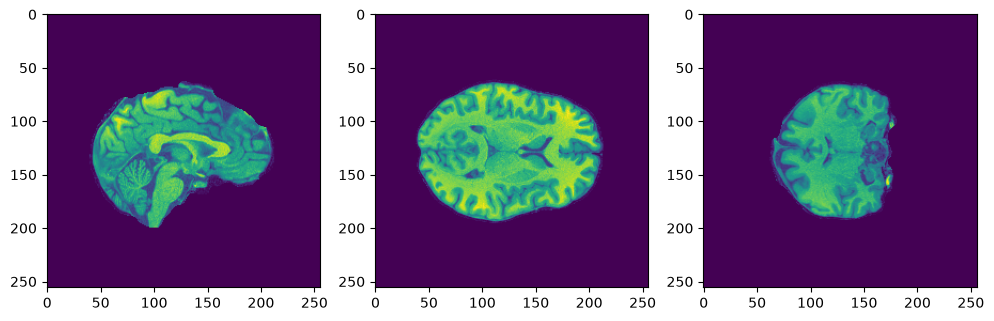

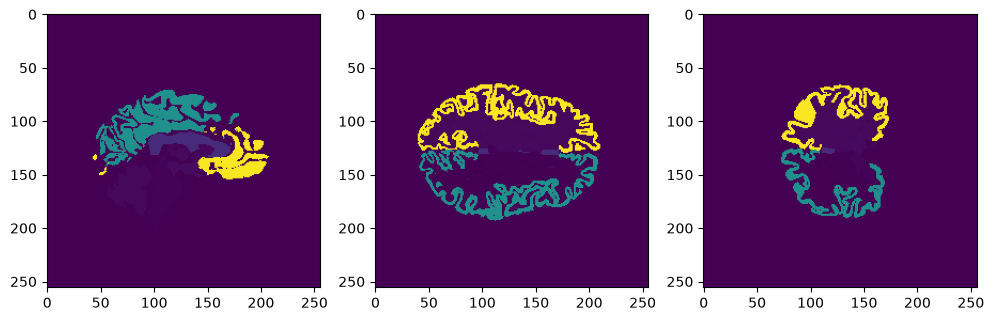

In [14]:
img = data[0][MRI]
seg = data[0][LABEL]
print("image shape:", img.shape, "| segmentation shape:", seg.shape)
plot_central_cuts(img[DATA])
plot_central_cuts(seg[DATA])

### The split

In [15]:
from sklearn.model_selection import train_test_split

SUBSET = 40          # set to None to use every subject (slow!)
TRAIN_FRACTION = 0.7

idx = np.arange(len(subjects))
rng = np.random.default_rng(0)
rng.shuffle(idx)
if SUBSET:
    idx = idx[:SUBSET]

train_idx, val_idx = train_test_split(idx, train_size=TRAIN_FRACTION, random_state=0)

training_subjects   = [subjects[i] for i in train_idx]
validation_subjects = [subjects[i] for i in val_idx]

assert not (set(train_idx) & set(val_idx))       # no subject in both

training_set   = torchio.SubjectsDataset(training_subjects,   transform=None)
validation_set = torchio.SubjectsDataset(validation_subjects, transform=None)

print(f"training {len(training_set)} | validation {len(validation_set)} subjects")

training 28 | validation 12 subjects


Whole volumes are heavy, so one subject per batch.

In [16]:
num_workers = 0 if os.name == "nt" else multiprocessing.cpu_count()

training_loader = torch.utils.data.DataLoader(
    training_set, batch_size=1, shuffle=True, num_workers=num_workers)
validation_loader = torch.utils.data.DataLoader(
    validation_set, batch_size=1, num_workers=num_workers)

## 5. Metrics, loss, and the training loop

A few notes on what's here.

`prepare_batch` is where the **binarisation** happens: every label in `LIST_ASEG` (plus the cortical parcellation IDs ≥ 1000) becomes 1, everything else 0. This is the "binary" decision from the intro made concrete - the multi-class exercise at the end starts by changing this function.

Dice loss is computed over both channels, background included. Since background is most of the volume and trivially easy, it drags the reported number toward optimism - that's why "loss < 0.7" counts as a decent result here rather than something near zero. Worth knowing when you read the curve.

In [17]:
def get_iou_score(prediction, ground_truth):
    intersection, union = 0, 0
    intersection += np.logical_and(prediction > 0, ground_truth > 0).astype(np.float32).sum()
    union += np.logical_or(prediction > 0, ground_truth > 0).astype(np.float32).sum()
    iou_score = float(intersection) / union
    return iou_score

def calculate_metrics(surface, prediction):
    dsc = compute_dice_coefficient(surface, prediction)
    asd_mean, asd_std = compute_average_surface_distance(
        compute_surface_distances(
            surface, prediction, spacing_mm=(1,1,1))
    )

    iou = get_iou_score(prediction, surface)

    return dsc, asd_mean, asd_std, iou

## see more in https://github.com/deepmind/surface-distance
def validate_dsc_asd(model, loader):
    '''
    Function to get metrics on valiadtion loader
    '''

    dsc, asd_mean, asd_std, iou = [], [], [], []
    model.eval()

    for batch_idx, batch in enumerate(tqdm(loader)):
            inputs, targets = prepare_batch(batch, device)
            with torch.no_grad():
                logits = forward(model, inputs)
            labels = logits.argmax(dim=CHANNELS_DIMENSION)
            prediction = labels[0].cpu().numpy().astype(np.uint8)
            dsc_temp, asd_mean_temp, asd_std_temp, iou_temp = calculate_metrics(
                targets.cpu().numpy().astype(np.uint8)[0][0],
                prediction
            )
            dsc.append(dsc_temp)
            asd_mean.append(asd_mean_temp)
            asd_std.append(asd_std_temp)
            iou.append(iou_temp)

    return dsc, asd_mean, asd_std, iou

def prepare_batch(batch, device):
    """
    The function loaging *nii.gz files, sending to the device.
    For the LABEL in binarises the data.
    """
    inputs = batch[MRI][DATA].to(device)
    targets = batch[LABEL][DATA]
    targets[0][0][(np.isin(targets[0][0], LIST_ASEG))] = 1
    targets[targets >= 1000] = 1
    targets[targets != 1] = 0
    targets = targets.to(device)
    return inputs, targets

def get_dice_score(output, target, SPATIAL_DIMENSIONS = (2, 3, 4), epsilon=1e-9):
    p0 = output
    g0 = target
    p1 = 1 - p0
    g1 = 1 - g0
    tp = (p0 * g0).sum(dim=SPATIAL_DIMENSIONS)
    fp = (p0 * g1).sum(dim=SPATIAL_DIMENSIONS)
    fn = (p1 * g0).sum(dim=SPATIAL_DIMENSIONS)
    num = 2 * tp
    denom = 2 * tp + fp + fn + epsilon
    dice_score = num / denom
    return dice_score

def get_dice_loss(output, target):
    return 1 - get_dice_score(output, target)

def forward(model, inputs):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        logits = model(inputs)
    return logits

def run_epoch(epoch_idx, action, loader, model, optimizer, scheduler=False, experiment= False):
    is_training = action == Action.TRAIN
    epoch_losses = []
    model.train(is_training)

    for batch_idx, batch in enumerate(tqdm(loader)):
        inputs, targets = prepare_batch(batch, device)
        optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            #main part
            logits = forward(model, inputs.float())
            probabilities = F.softmax(logits, dim=CHANNELS_DIMENSION)
            batch_losses = get_dice_loss(probabilities, targets)
            batch_loss = batch_losses.mean()

            if is_training:
                batch_loss.backward()
                optimizer.step()

            # appending the loss
            epoch_losses.append(batch_loss.item())

            if experiment:
                if action == Action.TRAIN:
                    experiment.log_metric("train_dice_loss", batch_loss.item())
                elif action == Action.VALIDATE:
                    experiment.log_metric("validate_dice_loss", batch_loss.item())

            del inputs, targets, logits, probabilities, batch_losses

    epoch_losses = np.array(epoch_losses)
    # print(f'{action.value} mean loss: {epoch_losses.mean():0.3f}')

    return epoch_losses

def train(num_epochs, training_loader, validation_loader, model, optimizer, scheduler,
          weights_stem, save_epoch= 1, experiment= False, verbose = True):

    start_time = time.time()
    epoch_train_loss, epoch_val_loss = [], []

    run_epoch(0, Action.VALIDATE, validation_loader, model, optimizer, scheduler, experiment)

    for epoch_idx in range(1, num_epochs + 1):

        epoch_train_losses = run_epoch(epoch_idx, Action.TRAIN, training_loader,
                                       model, optimizer, scheduler, experiment)
        epoch_val_losses = run_epoch(epoch_idx, Action.VALIDATE, validation_loader,
                                     model, optimizer, scheduler, experiment)

        # 4. Print metrics
        if verbose:
            clear_output(True)
            print("Epoch {} of {} took {:.3f}s".format(epoch_idx, num_epochs, time.time() - start_time))
            print("  training loss (in-iteration): \t{:.6f}".format(epoch_train_losses[-1]))
            print("  validation loss: \t\t\t{:.6f}".format(epoch_val_losses[-1]))

        epoch_train_loss.append(np.mean(epoch_train_losses))
        epoch_val_loss.append(np.mean(epoch_val_losses))

        # 5. Plot metrics
        if verbose:
            plt.figure(figsize=(10, 5))
            plt.plot(epoch_train_loss, label='train')
            plt.plot(epoch_val_loss, label='val')
            plt.xlabel('epoch')
            plt.ylabel('loss')
            plt.legend()
            plt.show()

        if scheduler:
            scheduler.step(np.mean(epoch_val_losses))
        # comet ml
        if experiment:
            experiment.log_epoch_end(epoch_idx)
        #saving the model
        if (epoch_idx% save_epoch == 0):
            if not os.path.exists('weights'): os.makedirs('weights')
            torch.save(model.state_dict(), f'weights/{weights_stem}_epoch_{epoch_idx}.pth')

In [18]:
def get_model_and_optimizer(device, num_encoding_blocks=3, out_channels_first_layer=4, patience=3):
  # Better to train with num_encoding_blocks=3, out_channels_first_layer = 16 '''

  # repoducibility
  torch.manual_seed(0)
  np.random.seed(0)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

  model = UNet(
        in_channels=1,
        out_classes=2,
        dimensions=3,
        num_encoding_blocks=num_encoding_blocks,
        out_channels_first_layer=out_channels_first_layer,
        normalization='batch',
        upsampling_type='linear',
        padding=True,
        activation='PReLU',
    ).to(device)

  optimizer = torch.optim.AdamW(model.parameters())
#     scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.7)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=patience, threshold=0.01)

  return model, optimizer, scheduler

model, optimizer, scheduler = get_model_and_optimizer(device)

## 6. Whole-brain segmentation

~25 minutes on a GPU. The scheduler is passed through properly now (the original passed `scheduler=False` here, disabling the LR schedule it had just built).

In [ ]:
torch.cuda.empty_cache()

num_epochs = 5
weights_stem = 'whole_images'

train(num_epochs, training_loader, validation_loader,
      model, optimizer, scheduler=scheduler, weights_stem=weights_stem)

 18%|█▊        | 5/28 [02:09<08:04, 21.05s/it]

On the full sample with ~40 epochs you should see DICE above 0.9. With 5 epochs on a 40-subject subset, expect considerably less - the point here is the mechanics, not the number.

Let's see what it predicts.

In [ ]:
batch = next(iter(validation_loader))
model.eval()
inputs, targets = prepare_batch(batch, device)
with torch.no_grad():
    logits = forward(model, inputs.float())

labels_pred = logits.argmax(dim=CHANNELS_DIMENSION)
foreground = labels_pred[0].cpu().numpy().astype(np.uint8)
plot_central_cuts(foreground)

In [ ]:
plot_predicted(inputs, foreground, 30, title="prediction overlaid on input")

In [ ]:
plot_central_cuts(targets[0].cpu())   # ground truth

In [ ]:
print(labels_pred[0].size(), targets[0][0].size())
get_dice_score(labels_pred.unsqueeze(1).float(), targets.float())

## 7. Patch-based segmentation

Short on GPU memory, or on subjects? Cut each volume into patches and segment those. `torchio.Queue` samples patches on the fly.

Note we reuse the *same* `train()` / `run_epoch()` from above - only the loaders change.

In [ ]:
patch_size = 64
samples_per_volume = 8
max_queue_length = 240
patch_batch_size = 16

patches_training_set = torchio.Queue(
    subjects_dataset=training_set,
    max_length=max_queue_length,
    samples_per_volume=samples_per_volume,
    sampler=torchio.sampler.UniformSampler(patch_size),
    num_workers=num_workers,
    shuffle_subjects=True,
    shuffle_patches=True,
)
patches_validation_set = torchio.Queue(
    subjects_dataset=validation_set,
    max_length=max_queue_length,
    samples_per_volume=samples_per_volume,
    sampler=torchio.sampler.UniformSampler(patch_size),
    num_workers=num_workers,
    shuffle_subjects=False,
    shuffle_patches=False,
)

patch_training_loader   = torch.utils.data.DataLoader(patches_training_set,   batch_size=patch_batch_size)
patch_validation_loader = torch.utils.data.DataLoader(patches_validation_set, batch_size=patch_batch_size)

In [ ]:
model, optimizer, scheduler = get_model_and_optimizer(device)

num_epochs = 5
train(num_epochs, patch_training_loader, patch_validation_loader,
      model, optimizer, scheduler=scheduler, weights_stem='patches')

Inference happens per-patch, so to see a whole brain we have to stitch the patches back together: `GridSampler` cuts the volume up, `GridAggregator` reassembles the predictions.

In [ ]:
def predict_full_volume(model, sample, patch_size=(64, 64, 64), patch_overlap=(4, 4, 4), batch_size=16):
    grid_sampler = torchio.inference.GridSampler(sample, patch_size, patch_overlap)
    patch_loader = torch.utils.data.DataLoader(grid_sampler, batch_size=batch_size)
    aggregator = torchio.inference.GridAggregator(grid_sampler)

    model.eval()
    with torch.no_grad():
        for patches_batch in patch_loader:
            inputs = patches_batch[MRI][DATA].to(device).float()
            locations = patches_batch['location']
            logits = model(inputs)
            preds = logits.argmax(dim=CHANNELS_DIMENSION, keepdim=True)
            aggregator.add_batch(preds, locations)
    return aggregator.get_output_tensor()

sample = random.choice(validation_set)
plot_central_cuts(predict_full_volume(model, sample))

Now train it properly - 40 epochs. Expect loss below 0.7.

In [ ]:
model, optimizer, scheduler = get_model_and_optimizer(device)

num_epochs = 40
train(num_epochs, patch_training_loader, patch_validation_loader,
      model, optimizer, scheduler=scheduler, weights_stem='patches')

In [ ]:
sample = random.choice(validation_set)
plot_central_cuts(predict_full_volume(model, sample))

## 8. Exercise: go multi-class

Everything above is binary - brain-structure vs background. But the `aseg` volume knows the difference between a hippocampus and a ventricle, and we threw that away. Recover it.

Three things have to change together:

1. **`prepare_batch`** - stop collapsing to 0/1. Map each label in `LIST_ASEG` to a contiguous class index (0 = background, 1..N = structures). `torch.bucketize` or a lookup tensor is cleaner than a chain of masks.
2. **`get_model_and_optimizer`** - `out_classes=2` becomes `out_classes=len(LIST_ASEG) + 1`.
3. **The loss** - Dice over N classes needs one-hot targets, and you'll want to *exclude background* from the mean, or the easy background class will dominate the score exactly as it partly does now. Cross-entropy + Dice together is the usual pairing.

Then ask the interesting question: does per-structure Dice look anything like the binary Dice? Small structures (amygdala, 5th ventricle) are much harder than big ones, and a single averaged number hides that completely. Report Dice *per class*.

### Other things worth trying

1. Crop the empty corners. You're spending compute on air.
2. Bigger patches beat smaller ones - 128³ if memory allows.
3. Is the U-Net deep enough? Wide enough? Watch your memory.
4. Augmentation is essentially mandatory for patch-based training (rotation, smoothing), but it roughly doubles training time.
5. Adjust the learning rate as you go - the scheduler is already wired up.

**Probably not worth your time:** patch-location as a model input, focal loss, training only on non-zero patches.